# Diseño de Filtro Pasa Bajos Butterworth de Orden 6

Para establecer una transferencia $T_\text{LP}(s)$ que garantice la condición de máxima planicidad en el origen, debemos usar la teoría de la aproximación y encontrar la transferencia que responda a $$|T_n(j\omega)|² = \frac{1}{1 + \varepsilon²\,\omega^{2n}}$$
Si particularizamos para una respuesta Butterworth $(\varepsilon² = 1)$, tenemos $$|T_n(j\omega)|² = \frac{1}{1 + \omega^{2n}}$$
y la ubicación de los polos en el plano complejo $s$ se encuentran en

$$
\begin{aligned}
\text{n impar: } & \theta_k = k\,\frac{\pi}{n} \quad & k = \{0, 1, \dots, 2n - 1\} \\\\
\text{n par: } & \theta_k = k\,\frac{\pi}{n} + \frac{\pi}{2\,n} \quad & k = \{0, 1, \dots, 2n - 1\}
\end{aligned}
$$
Si se trata de un orden 6, entonces $$|T_6(j\omega)|² = \frac{1}{1 + \omega^{12}}$$ $n = 6$ y $\theta_k= k\,\frac{\pi}{6} + \frac{\pi}{12}$ donde $k = \{{0, 1, \dots, 11}\}$

$$
\begin{array}{|c|c|}
\hline
k & \theta_k \\
\hline
0 & \frac{\pi}{12} = 15^\circ \\
\hline
1 & \frac{3\pi}{12} = 45^\circ \\
\hline
2 & \frac{5\pi}{12} = 75^\circ \\
\hline
3 & \frac{7\pi}{12} = 105^\circ \\
\hline
4 & \frac{9\pi}{12} = 135^\circ \\
\hline
5 & \frac{11\pi}{12} = 165^\circ \\
\hline
6 & \frac{13\pi}{12} = 195^\circ \\
\hline
7 & \frac{15\pi}{12} = 225^\circ \\
\hline
8 & \frac{17\pi}{12} = 255^\circ \\
\hline
9 & \frac{19\pi}{12} = 285^\circ \\
\hline
10 & \frac{21\pi}{12} = 315^\circ \\
\hline
11 & \frac{23\pi}{12} = 345^\circ \\
\hline
\end{array}
$$

A continuación, se presenta el diagrama de polos y ceros distribuidos en el plano complejo $s$


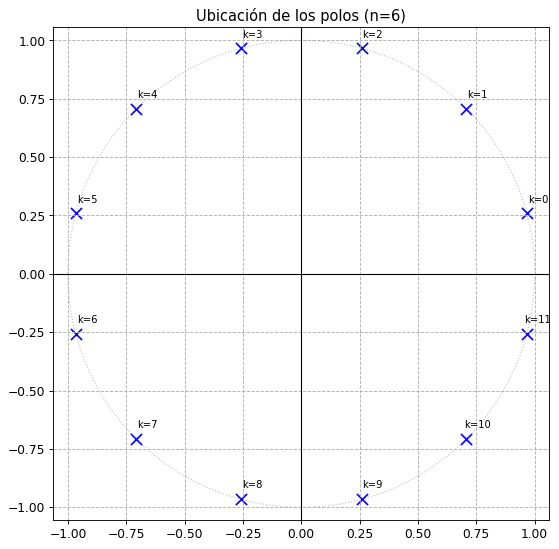

In [25]:
import numpy as np
import matplotlib.pyplot as plt

n = 6
k_values = np.arange(2 * n)
# Cálculo de la fase para n par: (k*pi/n) + pi/(2n)
theta = (k_values * np.pi / n) + (np.pi / (2 * n))
polos = np.exp(1j * theta)

plt.figure(figsize=(8,8))
plt.scatter(np.real(polos), np.imag(polos), marker='x', color='blue', s=100)

# Agregamos las etiquetas para cada k
for i, k in enumerate(k_values):
    plt.annotate(f'k={k}', 
                 (np.real(polos[i]), np.imag(polos[i])),
                 textcoords="offset points", # Cómo posicionar el texto
                 xytext=(10,10),             # Distancia (x,y) desde el polo
                 ha='center',                # Alineación horizontal
                 fontsize=9)

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, which='both', linestyle='--')
plt.title('Ubicación de los polos (n=6)')
plt.axis('equal')

# Dibujamos el círculo unitario para referencia
circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle=':', alpha=0.5)
plt.gca().add_artist(circulo)

plt.show()

Notar que los 12 polos se sitúan sobre una circunferencia de radio $\omega_0 = 1 \frac{\text{rad}}{s}$, y además se encuentran distribuidos simétricamente en ambos semiplanos. Esto se debe a que para obtener la máxima planicidad se parte de $|T(j\omega)|^2 = T(s) \cdot T(-s) \Big|_{s=j\omega}$

Para garantizar la estabilidad del filtro, se deben considerar únicamente aquellos polos que se encuentren en el semiplano complejo izquierdo $(\sigma < 0)$, estos son $$\theta_3\,, \theta_4\,, \theta_5\,, \theta_6\,, \theta_7 \,\,\text{y} \,\theta_8,$$
Si tomamos la transferencia del filtro Butterworth de orden $n$ $$|T_n(j\omega)| = \frac{1}{\sqrt{1 + \omega^{2n}}}$$ y la expresamos en dB
$$|T_n(j\omega)|_{\text{d}B} = 20\,\log{(\frac{1}{\sqrt{1 + \omega^{2n}}})}$$
$$|T_n(j\omega)|_{\text{d}B} = -10\,\log{(1 + \omega^{2n})}$$
Si $\omega >> 1$ entonces $$|T_n(j\omega)|_{\text{d}B} \approx -10\log{(\omega^{2n})}$$
$$|T_n(j\omega)|_{\text{d}B} \approx -20\,n\log{(\omega)}$$
En escala logarítmica, el módulo de la transferencia sufrirá una caída de $-20\,n \frac{dB}{dec}$ cuando ocurra que $\omega >> 1$. Por lo tanto, si $n = 6$, nuestro filtro Butterworth tendrá una caída de $-120 \frac{\text{d}B}{dec}$ en dichas condiciones.

Otro punto de interes es en $|T_6(j\omega)| \Big|_{\omega = \omega_0} = -10\log{(1+1^{12})} = -10\log(2) = -3 \,\text{d}B$

De este modo, es esperable que nuestra transferencia en módulo describa el siguiente comportamiento

<figure style="text-align: center;">
    <img src="images/btr6.jpeg" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 1: Rta. en frecuencia cualitativa de una transferencia Pasa Bajos de orden 6.</figcaption>
</figure>

Y en cuanto a la respuesta de fase $\phi(\omega) = \Sigma\,\phi_{\text{ceros}} -\Sigma\,\phi_{\text{polos}}$
$$\begin{aligned}
\omega = 0: & \quad \phi(\omega) = 0^\circ - 0^\circ = 0^\circ \\
\omega = \omega_0: & \quad \phi(\omega) = 0^\circ - (90^\circ + 90^\circ + 90^\circ) = -270^\circ \\
\omega \to \infty: & \quad \phi(\omega) = 0^\circ - (90^\circ + 90^\circ + 90^\circ + 90^\circ + 90^\circ + 90^\circ) = -540^\circ
\end{aligned}$$

Estos valores se determinaron a partir de una visualización gráfica en el diagrama de polos y ceros,analizando como varía el aporte de fase de cada polo en el semiplano izquierdo a medida que desplazamos la frecuencia en el eje $j\omega$.

<figure style="text-align: center;">
    <img src="images/fase.jpeg" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 2: Rta. de fase cualitativa de una transferencia Pasa Bajos de orden 6.</figcaption>
</figure>

## Obtención de la Transferencia Pasa Bajos
De forma general, una sección de segundo orden estable describirá en el plano complejo la siguiente configuración de polos
<figure style="text-align: center;">
    <img src="images/gralp.jpeg" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura 3: Polos complejos conjugados de una sección de segundo orden.</figcaption>
</figure>

con $\quad p = -\alpha + j\beta \quad$ y $\quad p* = -\alpha - j\beta$ para garantizar la estabilidad del filtro.

Una respuesta con un comportamiento pasa bajos responde de la forma $$T(s) = \frac{\omega_0²}{(s - p)\,(s - p*)} = \frac{\omega_0²}{s² - s\,(p + p*) + p\,p*}$$
donde $\quad p + p* = -2\,\alpha \quad$ , $\quad p\,p* = \omega_0² \quad$ y $\quad \alpha = \omega_0\,\cos(\psi)$

Reemplazando donde corresponda se tiene $$T(s) = \frac{\omega_0²}{s² + s\,2\,\omega_0\,\cos(\psi) + \omega_0²}$$
y como estamos operando en la frecuencia normalizada $\omega_0 = 1 \frac{\text{rad}}{s}$, entonces $$T(s) = \frac{1}{s² + s\,2\,\cos(\psi) + 1}$$
Esto nos da la pauta de que cada par de polos complejos conjugados define una sección de segundo orden (S0S) de la transferencia total.  Solo hace falta conocer la fase relativa $\psi_k$ desde el semieje negativo de $\sigma$

$$
\begin{array}{|c|c|}
\hline
k & \psi_k \\
\hline
3 & 75^\circ \\
\hline
4 & 45^\circ \\
\hline
5 & 15^\circ \\
\hline
\end{array}
$$
De este modo, las tres Secciones de Segundo Orden que describen a nuestro filtro Butterworth de orden 6 son: 
$$T_{k = 3}\,(s) = \frac{1}{s² + s\,0.52 + 1} \quad,\quad Q_3 = \frac{1}{2\,\cos(\psi_3)} = \frac{1}{0.52} = 1.92$$
$$T_{k = 4}\,(s) = \frac{1}{s² + s\,1.41 + 1} \quad,\quad Q_4 = \frac{1}{2\,\cos(\psi_4)} = \frac{1}{1.41} = 0.71$$
$$T_{k = 5}\,(s) = \frac{1}{s² + s\,1.93 + 1} \quad,\quad Q_5 = \frac{1}{2\,\cos(\psi_5)} = \frac{1}{1.93} = 0.52$$

Y esto tiene mucho sentido ya que si vamos en orden creciente de $k$, los polos se "alejan" del eje $j\omega$, disminuyendo así el valor de $Q$.

La combinación en cascada de estás tres secciones se pueden expresar mediante el producto
$$T_{LP}\,(s) = T_{k = 5}\,(s)\,T_{k = 4}\,(s)\,T_{k = 3}\,(s)$$
$$T_{LP}\,(s) = \frac{1}{(s² + s\,1.93 + 1)}\,\frac{1}{(s² + s\,1.41 + 1)}\,\frac{1}{(s² + s\,0.52 + 1)}$$
el cual garantizará una transferencia con un comportamiento Pasa Bajos Butterworth de orden 6 con Máxima Planicidad en el origen.

## Implementación de la red activa
Se propone implementar una red activa normalizada configurando tres SOS en el siguiente orden ($Q$ creciente): $Q_5 < Q_4 < Q_3$

<div align="center">
    Sallen Key $\rightarrow$ KHN $\rightarrow$ MFB
</div>

### Topología Sallen-Key (SOS_1)
<figure style="text-align: center;">
    <img src="images/sallen.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 4: Red activa pasa bajos 2do orden (Sallen-Key).</figcaption>
</figure>

Plantenado las ecuaciones en los nodos de interés mediante el método sistemático: 
$$
\begin{aligned}
\text{Nodo } V_a: & \quad V_a(G_2 + sC1) - V_c G_2 = 0 & \text{(1)} \\
\text{Nodo } V_b: & \quad V_b(G_3 + G_4) - V_o G_4 = 0 & \text{(2)} \\
\text{Nodo } V_c: & \quad V_c(G_1 + G_2 + sC2) - V_i G_1 - V_a G_2 - V_o sC2 = 0 & \text{(3)}\\
\text{Op. Amp. ideal}: & \quad V_a = V_b & \text{(4)}
\end{aligned}
$$

$(4)$ en $(2)$: $$V_a = V_o\,\frac{G_4}{G_3 + G_4} \quad (5)$$

$(5)$ en $(3)$: $$V_c = \frac{V_i\,G_1\,(G_3 + G_4) + V_o\,[G_2\,G_4 + s\,(G_3 + G_4)\,C_2]}{(G_3 + G_4)\,(G_1 + G_2 + sC_2)} \quad (6)$$

Reemplazando $(5)$ y $(6)$ en $(1)$ y planteando el cociente $\frac{V_o}{V_i}$ se obtiene
$$T_{k = 5}\,(s) = \frac{V_o}{V_i} = \frac{\frac{G_1\,G_2(G_3 + G_4)}{G_4\,C_1\,C_2}}{s² + s\,(\frac{G_1 + G_2}{C_2} + \frac{G_2}{C_1} - \frac{G_2\,(G_3 + G_4)}{G_4\,C_1}) + \frac{G_1\,G_2}{C_1\,C_2}}$$

Expresada en términos de resistencias:
$$T_{k = 5}\,(s) = \frac{\frac{R_3 + R_4}{R_1\,R_2\,R_3\,C_1\,C_2}}{s^2 + s\,(\frac{R_1 + R_2}{R_1\,R_2\,C_2} + \frac{1}{R_2\,C_1} - \frac{(R_3 + R_4)}{R_2\,R_3\,C_1}) + \frac{1}{R_1\,R_2\,C_1\,C_2}}$$

$$T_{k = 5}\,(s) = \frac{R_3 + R_4}{R_3}\,\frac{\frac{1}{R_1\,R_2\,C_1\,C_2}}{s^2 + s\,(\frac{R_1 + R_2}{R_1\,R_2\,C_2} + \frac{1}{R_2\,C_1} - \frac{(R_3 + R_4)}{R_2\,R_3\,C_1}) + \frac{1}{R_1\,R_2\,C_1\,C_2}}$$

La cual responde a una transferencia canónica del tipo Pasa Bajos: $\quad T\,(s) = \frac{\omega_0²}{s^2 + s\,\frac{\omega_0}{Q} + \omega_0^2}$

Se adopta una norma de frecuencia $\Omega_\omega = \omega_0 \, [\frac{\text{rad}}{s}]$ y una norma de impedancia $\Omega_z = R \, [\Omega]$. De este modo, los valores normalizados se pueden expresar de la siguiente forma

$R_i'= \frac{R_i}{\Omega_z} = \frac{R_i}{R} \quad \text{y} \quad C_j'= C_j\,\Omega_z\,\Omega_\omega = C_j\,R\,\omega_0 \quad$ donde $\quad i = \{1,2,...,4\} \,$ y $\, j = \{1,2\}$

Entonces a partir de $$\omega_0 = \frac{1}{\sqrt{R_1\,R_2\,C_1\,C_2}}$$
y reemplazando por las expresiones previamente presentadas
$$\omega_0 = \frac{1}{\sqrt{R_1'R\,R_2'R\,\frac{C_1'}{R\,\omega_0}\,\frac{C_2'}{R\,\omega_0}}} = \frac{\omega_0}{\sqrt{R_1'\,R_2'\,C_1'\,C_2'}}$$
Finalmente queda que la frecuencia de corte normalizada es $$\omega_0' = \frac{1}{\sqrt{R_1'\,R_2'\,C_1'\,C_2'}} = 1$$
Y para que esto se cumpla, propongo $R_1' = R_2' = 1 \quad$ y $\quad C_1' = C_2' = 1$ 

Según los coeficientes que se obtuvieron al hallar la transferencia de la sección $T_{k = 5}\,(s)$, se debe cumplir que
$$\frac{\omega_0}{Q} = 1.93$$ $$\frac{\omega_0}{Q} = \omega_0\,(\frac{R_1' + R_2'}{R_1'\,R_2'\,C_2'} + \frac{1}{R_2'\,C_1'} - \frac{(R_3' + R_4')}{R_2'\,R_3'\,C_1'}) \quad \Rightarrow \quad \frac{1}{Q} = \frac{R_1' + R_2'}{R_1'\,R_2'\,C_2'} + \frac{1}{R_2'\,C_1'} - \frac{(R_3' + R_4')}{R_2'\,R_3'\,C_1'}$$ $$\frac{R_1' + R_2'}{R_1'\,R_2'\,C_2'} + \frac{1}{R_2'\,C_1'} - (1 + \frac{R_4'}{R_3'})\,\frac{1}{R_2'\,C_1'} = 1.93$$
Notar que el factor $(1 + \frac{R_4'}{R_3'})$ es la ganancia $K$. Reemplazando los valores normalizados queda
$$3 - K = 1.93$$
$$ K = 1.07$$
Con la ganancia establecida, propongo $R_3' = 1$, entonces de $K = 1 + \frac{R_4'}{R_3'} \quad \Rightarrow \quad R_4' = 0.07$.

Finalmente, la red normalizada queda como
<figure style="text-align: center;">
    <img src="images/sallennorm.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 5: Red activa pasa bajos normalizada 2do orden (Sallen-Key).</figcaption>
</figure>
Cuya respuesta en frecuencia y respuesta de fase es
<figure style="text-align: center;">
    <img src="images/sallenrta.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 6: Respuesta en frecuencia y Respuesta de fase Pasa Bajos Sallen Key 2do orden ~.ac dec 100 0.01 10~</figcaption>
</figure>
<figure style="text-align: center;">
    <img src="images/sallencursor.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura x: Valor característico de la transferencia en la frecuencia de corte</figcaption>
</figure>
Los valores normalizados de los componentes permiten que los valores de $\omega_0$ y $Q$ sean $1 \frac{\text{rad}}{s}$ y $0.52$, respectivamente

### Topología KHN (SOS_2)
<figure style="text-align: center;">
    <img src="images/khn.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 7: Red activa 2do orden (KHN).</figcaption>
</figure>

Para la salida Pasa Banda, es posible observar que está en una configuración inversora, esto es $$V_{BP} = V_{HP}\,(\frac{-\frac{1}{sC_1}}{R4}) = -V_{HP}\,\frac{1}{s\,R_4\,C_1} \quad (1)$$

Del mismo modo, para la salida Pasa Bajos se tiene $$V_{LP} = -V_{BP}\,\frac{1}{s\,R_5\,C_2} \quad (2)$$
Para hallar la tensión $V_{HP}$, planteamos las ecuaciones en los nodos de interés mediante el método sistemático
$$
\begin{aligned}
\text{Nodo } V_a: & \quad V_a(G_1 + G_2 + G_3) - V_{HP}\,G_3 - V_i\,G_1 - V_{LP}\,G_2= 0 & \text{(3)} \\
\text{Nodo } V_b: & \quad V_b(G_6 + G_7) - V_{BP}\,G_6 = 0 & \text{(4)} \\
\text{Op. Amp. ideal}: & \quad V_b = V_a & \text{(5)}
\end{aligned}
$$
En base a estas $5$ ecuaciones se puede hallar cualquiera de las siguientes salidas: $V_{HP}$, $V_{BP}$, $V_{LP}$. Conviene primero hallar $V_{HP}$ y luego multiplicarla por los integradores para obtener el resto de transferencias mencionadas.

Haciendo el trabajo algebraico se llega a que: 

$$\frac{V_{HP}}{V_{i}} = \frac{-R_3}{R_1}\,\frac{s^2}{s² + s\,(\frac{R_7\,[R_3\,(R_1 + R_2) + R_1\,R_2]}{R_1\,R_2\,R_4\,C_1\,(R_6 + R_7)}) + \frac{R_3}{R_2\,R_4\,R_5\,C_1\,C_2}}$$

Para obtener la transferencia Pasa Banda, pasamos por el integrador y debemos multiplicar por el factor $\frac{-1}{s\,R_4\,C_1}$ según indica la ecuación $(1)$

$$\frac{V_{BP}}{V_{i}} = \frac{R_3}{R_1\,R_4\,C_1}\,\frac{s}{s² + s\,(\frac{R_7\,[R_3\,(R_1 + R_2) + R_1\,R_2]}{R_1\,R_2\,R_4\,C_1\,(R_6 + R_7)}) + \frac{R_3}{R_2\,R_4\,R_5\,C_1\,C_2}}$$

Y para la transferencia Pasa Bajos (la que nos importa), pasamos por el otro integrador y multiplicamos por el factor $\frac{-1}{s\,R_5\,C_2}$ según indica la ecuación $(2)$
$$T_{k = 4}\,(s) = \frac{V_{LP}}{V_{i}} = \frac{-R_2}{R_1}\,\frac{\frac{R_3}{R_2\,R_4\,R_5\,C_1\,C_2}}{s^2 + s\,(\frac{R_7\,[R_3\,(R_1 + R_2) + R_1\,R_2]}{R_1\,R_2\,R_4\,C_1\,(R_6 + R_7)}) + \frac{R_3}{R_2\,R_4\,R_5\,C_1\,C_2}}$$

La cual responde a una transferencia canónica del tipo Pasa Bajos: $\quad T\,(s) = \frac{K \cdot \omega_0^2}{s^2 + s\,\frac{\omega_0}{Q} + \omega_0^2}$

Se adopta una norma de frecuencia $\Omega_\omega = \omega_0 \, [\frac{\text{rad}}{s}]$ y una norma de impedancia $\Omega_z = R \, [\Omega]$. De este modo, los valores normalizados se pueden expresar de la siguiente forma

$R_i'= \frac{R_i}{\Omega_z} = \frac{R_i}{R} \quad \text{y} \quad C_j'= C_j\,\Omega_z\,\Omega_\omega = C_j\,R\,\omega_0 \quad$ donde $\quad i = \{1,2,...,7\} \,$ y $\, j = \{1,2\}$

Entonces a partir de $$\omega_0 = \sqrt{\frac{R_3}{R_2\,R_4\,R_5\,C_1\,C_2}}$$
y reemplazando por las expresiones previamente presentadas
$$\omega_0 = \sqrt{\frac{R_3'R}{R_2'R\,R_4'R\,R_5'R\,\frac{C_1'}{R\,\omega_0}\,\frac{C_2'}{R\,\omega_0}}} = \omega_0\,\sqrt{\frac{R_3'}{R_2'\,R_4'\,R_5'\,C_1'\,C_2'}}$$
Finalmente queda que la frecuencia de corte normalizada es $$\omega_0' = \sqrt{\frac{R_3'}{R_2'\,R_4'\,R_5'\,C_1'\,C_2'}} = 1$$
Y para que esto se cumpla, propongo $R_2' = R_3' = R_4' = R_5' = 1 \quad$ y $\quad C_1' = C_2' = 1$

Según los coeficientes que se obtuvieron al hallar la transferencia de la sección $T_{k = 4}\,(s)$, se debe cumplir que
$$\frac{\omega_0}{Q} = 1.41$$
$$\frac{\omega_0}{Q} = \omega_0\,\left(\frac{R_7'\,[R_3'\,(R_1' + R_2') + R_1'\,R_2']}{R_1'\,R_2'\,R_4'\,C_1'\,(R_6' + R_7')}\right) \quad \Rightarrow \quad \frac{1}{Q} = \frac{R_7'\,[R_3'\,(R_1' + R_2') + R_1'\,R_2']}{R_1'\,R_2'\,R_4'\,C_1'\,(R_6' + R_7')}$$
$$\frac{R_7'\,[R_3'\,(R_1' + R_2') + R_1'\,R_2']}{R_1'\,R_2'\,R_4'\,C_1'\,(R_6' + R_7')} = 1.41$$
Notar que la ganancia de la etapa es $K = \frac{R_2'}{R_1'}$. Si queremos garantizar que la misma sea unitaria $(K = 1)$, tenemos $R_2' = 1 \quad \Rightarrow \quad R_1' = 1$. Reemplazando los valores normalizados queda
$$\frac{3\,R_7'}{R_6' + R_7'} = 1.41$$
$$\frac{R_6'}{R_7'} = 1.12$$
Con la relación establecida, propongo $R_7' = 1$, entonces de $\frac{R_6'}{R_7'} = 1.12 \quad \Rightarrow \quad R_6' = 1.12$

Finalmente, la red normalizada queda como
<figure style="text-align: center;">
    <img src="images/khnnorm.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura 8: Red activa pasa bajos normalizada 2do orden (KHN).</figcaption>
</figure>
Cuya respuesta en frecuencia y respuesta de fase es
<figure style="text-align: center;">
    <img src="images/khnrta.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura x: Respuesta en frecuencia y Respuesta de fase Pasa Bajos KHN 2do orden ~.ac dec 100 0.01 10~</figcaption>
</figure>
<figure style="text-align: center;">
    <img src="images/khncursor.png" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura x: Valor característico de la transferencia en la frecuencia de corte</figcaption>
</figure>
Los valores normalizados de los componentes permiten que los valores de $\omega_0$ y $Q$ sean $1 \frac{\text{rad}}{s}$ y $0.71$, respectivamente

### Topología MFB (SOS_3)
<figure style="text-align: center;">
    <img src="images/mfb.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura x: Red activa 2do orden (MFB).</figcaption>
</figure>

Planteando las ecuaciones en los nodos de interés mediante el método sistemático: 
$$
\begin{aligned}
\text{Nodo } V_a: & \quad V_a(G_2 + sC_2) - V_b G_2 - V_o sC_2= 0 & \text{(1)} \\
\text{Nodo } V_b: & \quad V_b(G_1 + G_2 + G_3 + sC_1) - V_i G_3 - V_a G_2 - V_o G_1 = 0 & \text{(2)} \\
\text{Op. Amp. ideal}: & \quad V_a = 0 V & \text{(3)}
\end{aligned}
$$
Reemplazando $(3)$ en $(1)$ se despeja la tensión $V_b$ y luego esta se reemplaza en $(1)$. Finalmente, la transferencia de la red queda
$$T_{k = 3}\,(s) = \frac{-R_1}{R_3}\,\frac{\frac{1}{R_1\,R_2\,C_1\,C_2}}{s^2 + s\,(\frac{1}{R_1\,C_1} + \frac{1}{R_2\,C_1} + \frac{1}{R_3\,C_1}) + \frac{1}{R_1\,R_2\,C_1\,C_2}}$$

La cual responde a una transferencia canónica del tipo Pasa Bajos: $\quad T\,(s) = \frac{K \cdot \omega_0^2}{s^2 + s\,\frac{\omega_0}{Q} + \omega_0^2}$

Nuevamente se adopta una norma de frecuencia $\Omega_\omega = \omega_0 \, [\frac{\text{rad}}{s}]$ y una norma de impedancia $\Omega_z = R \, [\Omega]$. De este modo, los valores normalizados se pueden expresar de la siguiente forma

$R_i'= \frac{R_i}{\Omega_z} = \frac{R_i}{R} \quad \text{y} \quad C_j'= C_j\,\Omega_z\,\Omega_\omega = C_j\,R\,\omega_0 \quad$ donde $\quad i = \{1,2,3\} \,$ y $\, j = \{1,2\}$

Entonces a partir de $$\omega_0 = \frac{1}{\sqrt{R_1\,R_2\,C_1\,C_2}}$$
y reemplazando 
$$\omega_0 = \frac{1}{\sqrt{R_1'R\,R_2'R\,\frac{C_1'}{R\,\omega_0}\,\frac{C_2'}{R\,\omega_0}}} = \frac{\omega_0}{\sqrt{R_1'\,R_2'\,C_1'\,C_2'}}$$
Finalmente, la frecuencia de corte normalizada es $$\omega_0' = \frac{1}{\sqrt{R_1'\,R_2'\,C_1'\,C_2'}} = 1 \quad \Rightarrow \quad R_1' = \frac{1}{R_2'\,C_1'\,C_2'}$$
Asimismo, la ganancia es $K = \frac{R_1'}{R_3'} \quad \Rightarrow \quad R_3' = \frac{R_1'}{K} = \frac{1}{R_2'\,C_1'\,C_2'\,K}$

Según los coeficientes que se obtuvieron al hallar la transferencia de la sección $T_{k = 3}\,(s)$, se debe cumplir que
$$\frac{\omega_0}{Q} = \omega_0\,\left(\frac{1}{R_1'\,C_1'} + \frac{1}{R_2'\,C_1'} + \frac{1}{R_3'\,C_1'}\right) \quad \Rightarrow \quad \frac{1}{Q} = \frac{1}{R_1'\,C_1'} + \frac{1}{R_2'\,C_1'} + \frac{1}{R_3'\,C_1'}$$

Despejando $R_2'$ desde la expresión del coeficiente lineal del denominador se llega a que
$$(R_2')^2 - R_2'\,\frac{1}{Q\,C_2'\,(1 + K)} + \frac{1}{C_1'\,C_2'\,(1 + K)} = 0$$
y resolviendo $$R_2' = \frac{1}{2\,Q\,C_2'\,(1 + K)} \pm \frac{1}{2}\,\sqrt{\frac{1}{Q^2\,(C_2')^2\,(1 + K)^2} - \frac{4}{C_1'\,C_2'\,(1 + K)}}$$
Planteando que el discriminante de la resolvente sea mayor o igual que 0 para tener soluciones reales se llega a una condición que deben cumplir los capacitores para garantizar Q elevados
$$\frac{1}{Q^2\,(C_2')^2\,(1 + K)^2} \geq \frac{4}{C_1'\,C_2'\,(1 + K)}$$
$$C_1' \geq 4\,Q^2\,(1 + K)\,C_2'$$

Contando con $Q = 1.92$ y $K = 1$, propongo $C_2' = 1$, entonces $C_1' \geq 29.49 \quad \Rightarrow \quad C_1' = 30$

Reemplazando en $R_2'$ se llega a que $R_2' = 0.1472 \quad \Rightarrow \quad R_1' = 0.2264$

y para garantizar ganancia unitaria $K = \frac{R_1'}{R_3'} = 1$, necesariamente $R_3' = 0.2264$.

Finalmente, la red normalizada queda como
<figure style="text-align: center;">
    <img src="images/mfbnorm1.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura x: Red activa pasa bajos normalizada 2do orden (MFB).</figcaption>
</figure>
Cuya respuesta en frecuencia y respuesta de fase es
<figure style="text-align: center;">
    <img src="images/mfbnorm.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura x: Respuesta en frecuencia y Respuesta de fase Pasa Bajos MFB 2do orden.</figcaption>
</figure>
<figure style="text-align: center;">
    <img src="images/mfbcursor.jpeg" alt="Descripción de la imagen" style="width: 30%;">
    <figcaption>Figura x: Valor característico de la transferencia en la frecuencia de corte</figcaption>
</figure>
Los valores normalizados de los componentes permiten que los valores de $\omega_0$ y $Q$ sean $1 \frac{\text{rad}}{s}$ y $1.92$, respectivamente

## Implementación Filtro Pasa Bajos Butterworth de Orden 6
La red Pasa Bajos de Orden 6 con máxima planicidad en la banda de paso configurada en cascada por tres secciones de Orden 2 es
<figure style="text-align: center;">
    <img src="images/bttrblackbox.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura x: Red activa Pasa Bajos 6to orden de Máxima Planicidad (Butterworth).</figcaption>
</figure>
Cuya respuesta en frecuencia y respuesta de fase es 
<figure style="text-align: center;">
    <img src="images/butterrta.png" alt="Descripción de la imagen" style="width: 70%;">
    <figcaption>Figura x: Respuesta en frecuencia y Respuesta de fase Pasa Bajos 6to orden Máx. Planicidad (Butterworth) ~.ac dec 100 0.01 10~</figcaption>
</figure>

La simulación Spice verifica que en $\omega_0 = 1 \frac{\text{rad}}{s}$ la atenuación es de aproximadamente $3 \text{dB}$ y con $\omega >> 1$ la amplitud cae a razón de $-120 \frac{\text{dB}}{\text{dec}}$
<div style="display: flex; justify-content: space-around; align-items: center;">
  <figure style="text-align: center; width: 45%;">
    <img src="images/bttrcursor.png" style="width: 100%;">
    <figcaption>Figura x: Valor característico de la transferencia en la frecuencia de corte</figcaption>
  </figure>
  <figure style="text-align: center; width: 45%;">
    <img src="images/bttrdif.png" style="width: 100%;">
    <figcaption>Figura x: Caída en dB/dec del filtro a frecuencias más altas que la frec. de corte</figcaption>
  </figure>
</div>